# **FASE 3.2 – Agrupamento de Dados: Análises Diversas**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.ticker import FuncFormatter
from kmodes.kmodes import KModes

### **Realizando a leitura da base de área de MG**

In [2]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Codificação das variáveis**
Nesse caso, será realizado a transformação da variável **TP_SEXO**, convertendo o valor 'M' para 0 e o valor 'F' para 1.

In [3]:
df_final["TP_SEXO"] = df_final["TP_SEXO"].map({"F": 1, "M": 0})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, a variável **TP_ESTADO_CIVIL** foi recodificada para valores numéricos, de forma que Solteiro(a) foi representado por 0, Casado(a)/Companheiro(a) por 1, e as demais categorias (Divorciado(a), Desquitado(a), Separado(a) e Viúvo(a)) foram agrupadas sob o valor 2, representando o grupo “Outros”

In [4]:
df_final["TP_ESTADO_CIVIL"] = df_final["TP_ESTADO_CIVIL"].replace({
    "Solteiro(a)": 0,
    "Casado(a)/Companheiro(a)": 1,
    "Divorciado(a)/Separado(a)": 2,
    "Desquitado(a)": 2,
    "Viúvo(a)": 2
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,1,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,0,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,1,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,0,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,1,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,0,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,1,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


Nesse caso, aplicou-se o método one-hot encoding à variável **TP_COR_RACA**, criando colunas binárias (0 e 1) para cada categoria de cor/raça. Essa transformação permite representar variáveis categóricas de forma numérica, sem atribuir uma ordem entre as categorias.

In [5]:
df_final = pd.get_dummies(df_final, columns=["TP_COR_RACA"], prefix="COR_RACA")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,1,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,1,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,1,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,1,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,1,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,3,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,1,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,1,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,1,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_NACIONALIDADE**, transformando as categorias originais em valores numéricos binários:

0 → Brasileiro(a), Brasileiro(a) Naturalizado(a) ou Brasileiro(a) Nato(a), nascido(a) no exterior

1 → Estrangeiro(a)

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [6]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_NACIONALIDADE"] != 0].copy()

df_final.loc[:, "TP_NACIONALIDADE"] = df_final["TP_NACIONALIDADE"].replace({
    1: 0,  # Brasileiro(a)
    2: 0,  # Brasileiro(a) Naturalizado(a)
    4: 0,  # Brasileiro(a) Nato(a), nascido(a) no exterior
    3: 1   # Estrangeiro(a)
})

depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517827
Total de linhas após a exclusão: 517522
Foram removidas 305 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,3.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,3.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_NACIONALIDADE**, o conjunto de dados passou de 517827 para 517522 registros, resultando na exclusão de 305 observações com nacionalidade “Não informada”.

Nesta etapa, será realizada a recodificação da variável **TP_ENSINO**, transformando as categorias originais em valores numéricos binários:

0 → Educação Especial – Modalidade Substitutiva e Educação de Jovens e Adultos

1 → Ensino Regular

As observações com valor 0 (Não informado) serão removidas do conjunto de dados.

In [7]:
df_final.loc[:, "TP_ENSINO"] = df_final["TP_ENSINO"].replace({
    2: 0,  # Educação Especial – Modalidade Substitutiva
    3: 0  # Educação de Jovens e Adultos
})
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,2,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,2,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,2,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,2,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,2,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,2,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,2,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,2,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,2,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Nesta etapa, será realizada a recodificação da variável **TP_ESCOLA**, transformando as categorias originais em valores numéricos binários:

0 → Pública

1 → Exterior e Privada

As observações com valor 1 (Não respondeu) serão removidas do conjunto de dados.

In [8]:
antes = len(df_final)
print(f"Total de linhas antes da exclusão: {antes}")

df_final = df_final[df_final["TP_ESCOLA"] != 1].copy()

df_final.loc[:, "TP_ESCOLA"] = df_final["TP_ESCOLA"].replace({
    2: 0,  # Pública
    3: 1,  # Exterior
    4: 1   # Privada
})
depois = len(df_final)
print(f"Total de linhas após a exclusão: {depois}")
print(f"Foram removidas {antes - depois} linhas (Não informadas).")
df_final

Total de linhas antes da exclusão: 517522
Total de linhas após a exclusão: 511774
Foram removidas 5748 linhas (Não informadas).


,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,D,A,A,A,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,D,A,A,B,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,B,B,B,B,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,B,A,A,A,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,C,A,B,B,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,C,A,A,B,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,D,A,A,B,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,E,A,D,B,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,D,A,B,B,False,False,False,True,False,False


Após a limpeza e recodificação da variável **TP_ESCOLA**, o conjunto de dados passou de 517522 para 511774 registros, resultando na exclusão de 5748 observações com nacionalidade “Não respondeu”.

Nesta etapa, será realizada a recodificação da variável **ESQ_PAI, ESC_MAE, OCU_PAI, OCU_MAE, RENDA_MENSAL, EMP_DOMESTICO, BANHEIRO, QTD_QUARTOS, CARRO, MOTO, GELADEIRA, FREEZER, LAVA_ROUPA, SECA_ROUPA, MICROONDAS, LAVA_LOUCA, ASPIRADOR, TV, DVD, TV_ASSINATURA, CELULAR, TELEFONE_FIXO, COMPUTADOR, INTERNET**, transformando as categorias originais em valores numéricos binários

In [9]:
colunas_categoricas = [
    'ESQ_PAI', 'ESC_MAE', 'OCU_PAI', 'OCU_MAE', 'RENDA_MENSAL',
    'EMP_DOMESTICO', 'BANHEIRO', 'QTD_QUARTOS', 'CARRO', 'MOTO',
    'GELADEIRA', 'FREEZER', 'LAVA_ROUPA', 'SECA_ROUPA', 'MICROONDAS',
    'LAVA_LOUCA', 'ASPIRADOR', 'TV', 'DVD', 'TV_ASSINATURA',
    'CELULAR', 'TELEFONE_FIXO', 'COMPUTADOR', 'INTERNET'
]
mapa = {chr(i + 65): i for i in range(26)}  # 'A'->0, 'B'->1, ..., 'Z'->25

for col in colunas_categoricas:
    df_final[col] = df_final[col].map(mapa)

df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
2,2018,11,0,0.0,0,2,0,0.0,Boa Esperança,MG,...,1.0,1.0,1.0,1.0,False,False,False,True,False,False
3,2018,12,1,0.0,0,2,0,0.0,Vespasiano,MG,...,1.0,0.0,0.0,0.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,0,1.0,1,2,0,NaN,Rio Vermelho,MG,...,2.0,0.0,0.0,1.0,False,False,True,False,False,False
517823,2023,2,1,1.0,0,2,0,1.0,Juiz de Fora,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517824,2023,2,0,1.0,0,2,0,1.0,Pouso Alegre,MG,...,4.0,0.0,3.0,1.0,False,True,False,False,False,False
517825,2023,2,1,1.0,0,2,0,1.0,Ipaba,MG,...,3.0,0.0,1.0,1.0,False,False,False,True,False,False


### **Filtrando a área de abrangencia do IFNMG**

In [10]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,SG_UF_ESC,...,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET,COR_RACA_0,COR_RACA_1,COR_RACA_2,COR_RACA_3,COR_RACA_4,COR_RACA_5
0,2018,3,0,0.0,0,2,0,1.0,Rio Pardo de Minas,MG,...,3.0,0.0,0.0,0.0,True,False,False,False,False,False
1,2018,2,1,0.0,0,2,0,1.0,São Francisco,MG,...,3.0,0.0,0.0,1.0,False,False,False,True,False,False
4,2018,2,0,0.0,0,2,0,1.0,Montalvânia,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
6,2018,2,0,0.0,0,2,0,1.0,Chapada do Norte,MG,...,2.0,0.0,1.0,1.0,False,False,False,True,False,False
9,2018,3,1,0.0,0,2,0,1.0,Teófilo Otoni,MG,...,4.0,0.0,1.0,1.0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,0.0,2.0,1.0,False,False,False,True,False,False
517781,2023,3,1,1.0,0,2,0,1.0,Montes Claros,MG,...,1.0,0.0,0.0,1.0,False,False,False,True,False,False
517789,2023,4,0,1.0,0,2,0,NaN,Teófilo Otoni,MG,...,3.0,0.0,0.0,1.0,False,True,False,False,False,False
517799,2023,2,0,1.0,0,2,0,1.0,Montes Claros,MG,...,4.0,1.0,2.0,1.0,False,False,False,True,False,False


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **K-modes de algumas variáveis [sexo, faixa etaria, tipo de escola e escolaridade e renda]**

Colunas encontradas no df_ifnmg: ['TP_SEXO', 'TP_FAIXA_ETARIA', 'TP_ESCOLA', 'TP_ENSINO', 'RENDA_MENSAL']

Formato da base para KModes: (69594, 5)
Primeiras linhas:
   TP_SEXO  TP_FAIXA_ETARIA  TP_ESCOLA  TP_ENSINO  RENDA_MENSAL
0        0                3          0        1.0           1.0
1        1                2          0        1.0           3.0
4        0                2          0        1.0           2.0
6        0                2          0        1.0           0.0
9        1                3          0        1.0           7.0
k=2 → custo=88422 | silhouette=0.3357
k=3 → custo=71254 | silhouette=0.3091
k=4 → custo=61031 | silhouette=0.3663
k=5 → custo=55424 | silhouette=0.2603
k=6 → custo=55634 | silhouette=0.3349
k=7 → custo=50389 | silhouette=0.2100
k=8 → custo=46891 | silhouette=0.2800
k=9 → custo=45380 | silhouette=0.3061


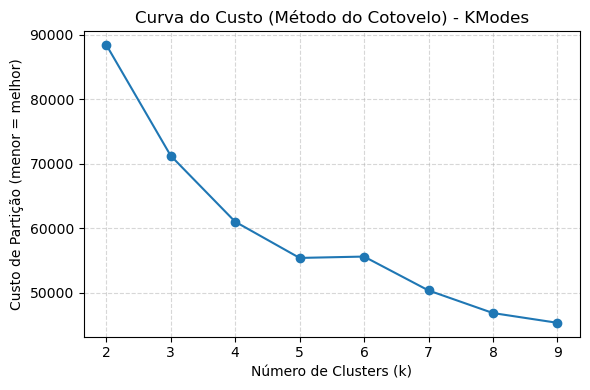

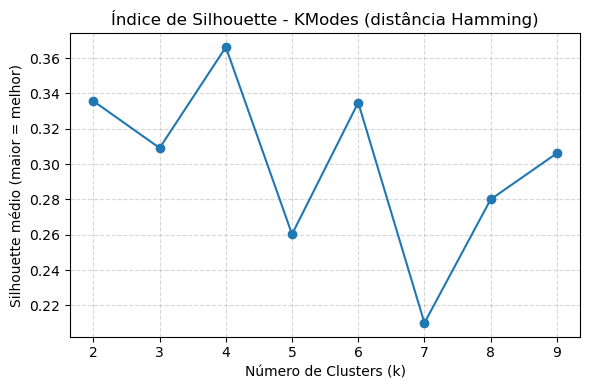


➡ Melhor k pelo menor custo: 9
➡ Melhor k pelo maior silhouette: 4

Quantidade de observações por cluster (k=5):
Cluster_KModes
0    20441
1    16006
2     9011
3     9939
4    14197
Name: count, dtype: int64

Modos (centroides) de cada cluster:
  TP_SEXO TP_FAIXA_ETARIA TP_ESCOLA TP_ENSINO RENDA_MENSAL  Cluster_KModes
0       1               3         0       1.0          2.0               0
1       0               3         0       1.0          1.0               1
2       0               2         0       1.0          2.0               2
3       1               3         0       1.0          1.0               3
4       1               2         0       1.0          1.0               4

% de sexo dentro de cada cluster:
TP_SEXO             0      1
Cluster_KModes              
0                13.8   86.2
1               100.0    0.0
2               100.0    0.0
3                 0.0  100.0
4                 0.0  100.0

% de tipo de escola dentro de cada cluster:
TP_ESCOLA          0

In [11]:
colunas_desejadas = ["TP_SEXO", "TP_FAIXA_ETARIA", "TP_ESCOLA", "TP_ENSINO", "RENDA_MENSAL"]

presentes = [c for c in colunas_desejadas if c in df_ifnmg.columns]
faltando = [c for c in colunas_desejadas if c not in df_ifnmg.columns]

print("Colunas encontradas no df_ifnmg:", presentes)
if faltando:
    print("⚠️ Atenção, essas colunas NÃO foram encontradas no df_ifnmg:", faltando)

# Base categórica sem NA
base_cat = df_ifnmg[presentes].dropna().copy()

print("\nFormato da base para KModes:", base_cat.shape)
print("Primeiras linhas:")
print(base_cat.head())

# Para o KModes: transformar em string (categórico)
X_kmodes = base_cat.astype(str).to_numpy()

# Para o silhouette: codificar as categorias como inteiros
base_cat_codes = base_cat.copy()
for c in base_cat_codes.columns:
    base_cat_codes[c] = base_cat_codes[c].astype("category").cat.codes
X_sil = base_cat_codes.to_numpy()

custos = []
silhuetas = []
Ks = range(2, 10)

for k in Ks:
    km = KModes(n_clusters=k, init="Huang", n_init=10, random_state=42)
    labels = km.fit_predict(X_kmodes)

    custo = km.cost_
    custos.append(custo)

    sil = silhouette_score(X_sil, labels, metric="hamming")
    silhuetas.append(sil)

    print(f"k={k} → custo={custo:.0f} | silhouette={sil:.4f}")

# Plot do custo
plt.figure(figsize=(6, 4))
plt.plot(Ks, custos, marker="o")
plt.title("Curva do Custo (Método do Cotovelo) - KModes")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Custo de Partição (menor = melhor)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Plot do silhouette
plt.figure(figsize=(6, 4))
plt.plot(Ks, silhuetas, marker="o")
plt.title("Índice de Silhouette - KModes (distância Hamming)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette médio (maior = melhor)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Melhor k por custo e por silhouette (apenas para você olhar, não para seguir cegamente)
melhor_k_custo = Ks[np.argmin(custos)]
melhor_k_sil = Ks[np.argmax(silhuetas)]

print(f"\n➡ Melhor k pelo menor custo: {melhor_k_custo}")
print(f"➡ Melhor k pelo maior silhouette: {melhor_k_sil}")

# Escolha manual do k (por ex.: 4 ou 5, depois de olhar os gráficos)
k_escolhido = 5   # <<< TROQUE AQUI QUANDO DEFINIR

kmodes_final = KModes(n_clusters=k_escolhido, init="Huang", n_init=10, random_state=42)
labels_final = kmodes_final.fit_predict(X_kmodes)

base_cat = base_cat.copy()
base_cat["Cluster_KModes"] = labels_final

print(f"\nQuantidade de observações por cluster (k={k_escolhido}):")
print(base_cat["Cluster_KModes"].value_counts().sort_index())

centroides = pd.DataFrame(kmodes_final.cluster_centroids_, columns=base_cat.columns[:-1])
centroides["Cluster_KModes"] = centroides.index
print("\nModos (centroides) de cada cluster:")
print(centroides)

df_ifnmg = df_ifnmg.copy()
df_ifnmg.loc[base_cat.index, "Cluster_KModes"] = base_cat["Cluster_KModes"].values

if "TP_SEXO" in presentes:
    print("\n% de sexo dentro de cada cluster:")
    print(
        (pd.crosstab(base_cat["Cluster_KModes"], base_cat["TP_SEXO"], normalize="index") * 100).round(1)
    )

if "TP_ESCOLA" in presentes:
    print("\n% de tipo de escola dentro de cada cluster:")
    print(
        (pd.crosstab(base_cat["Cluster_KModes"], base_cat["TP_ESCOLA"], normalize="index") * 100).round(1)
    )

print(f"\nA coluna 'Cluster_KModes' (k={k_escolhido}) foi adicionada ao df_ifnmg com sucesso!")
df_final["Cluster_KModes"] = df_ifnmg["Cluster_KModes"]

## **Análise dos Clusters**

## **Cenário do desempenho dos inscritos em cada um dos anos contemplados nas bases**


Contagem por ano e cluster:
   NU_ANO Cluster_Nome  Quantidade
0    2018     Perfil A        6174
1    2018     Perfil B        4448
2    2018     Perfil C        2367
3    2018     Perfil D        3341
4    2018     Perfil E        3765


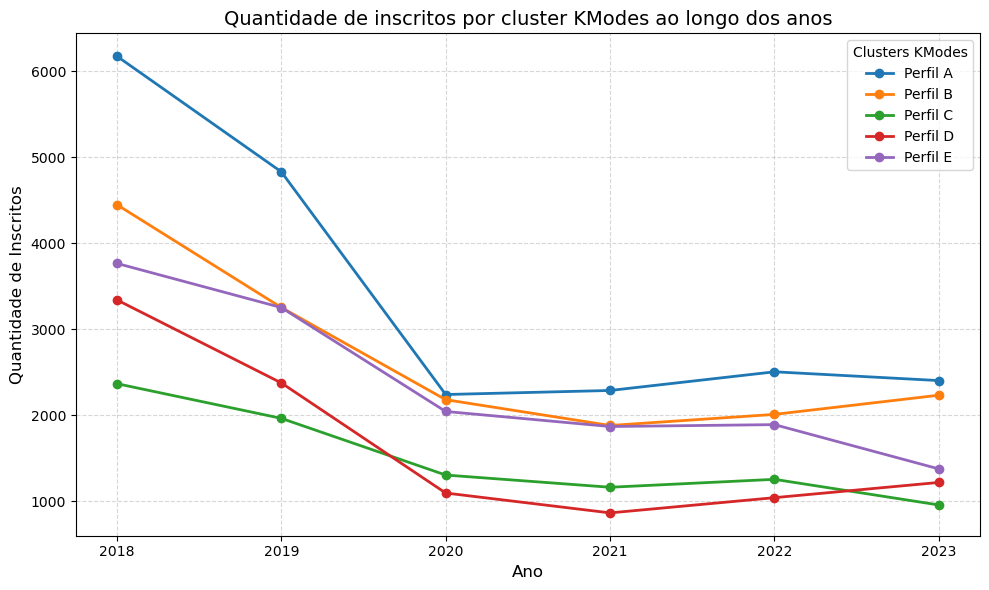


Porcentagem de cada cluster por ano (%):
Cluster_Nome  Perfil A  Perfil B  Perfil C  Perfil D  Perfil E
NU_ANO                                                        
2018              30.7      22.1      11.8      16.6      18.7
2019              30.8      20.8      12.5      15.2      20.7
2020              25.3      24.6      14.7      12.4      23.1
2021              28.4      23.3      14.4      10.7      23.2
2022              28.8      23.1      14.4      12.0      21.7
2023              29.3      27.3      11.7      14.9      16.8


In [12]:
nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D",
    4: "Perfil E"
}

df_ifnmg["Cluster_Nome"] = df_ifnmg["Cluster_KModes"].map(nomes_clusters)

colunas_necessarias = ["NU_ANO", "Cluster_KModes", "Cluster_Nome"]

for col in colunas_necessarias:
    if col not in df_ifnmg.columns:
        raise ValueError(f"A coluna {col} não existe no df_ifnmg!")

contagem_kmodes = (
    df_ifnmg.groupby(["NU_ANO", "Cluster_Nome"])
    .size()
    .reset_index(name="Quantidade")
)

print("\nContagem por ano e cluster:")
print(contagem_kmodes.head())

plt.figure(figsize=(10, 6))

clusters_unicos = contagem_kmodes["Cluster_Nome"].unique()

for nome in clusters_unicos:
    df_plot = contagem_kmodes[contagem_kmodes["Cluster_Nome"] == nome]
    plt.plot(
        df_plot["NU_ANO"],
        df_plot["Quantidade"],
        marker="o",
        linewidth=2,
        label=nome
    )

plt.title("Quantidade de inscritos por cluster KModes ao longo dos anos", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Inscritos", fontsize=12)
plt.legend(title="Clusters KModes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(sorted(df_ifnmg["NU_ANO"].unique()))
plt.tight_layout()
plt.show()

tabela_pct = (
    contagem_kmodes
    .pivot(index="NU_ANO", columns="Cluster_Nome", values="Quantidade")
    .apply(lambda x: (x / x.sum() * 100).round(1), axis=1)
)

print("\nPorcentagem de cada cluster por ano (%):")
print(tabela_pct)

## **Quantidade de inscritos por grupo para cada tipo de escola**

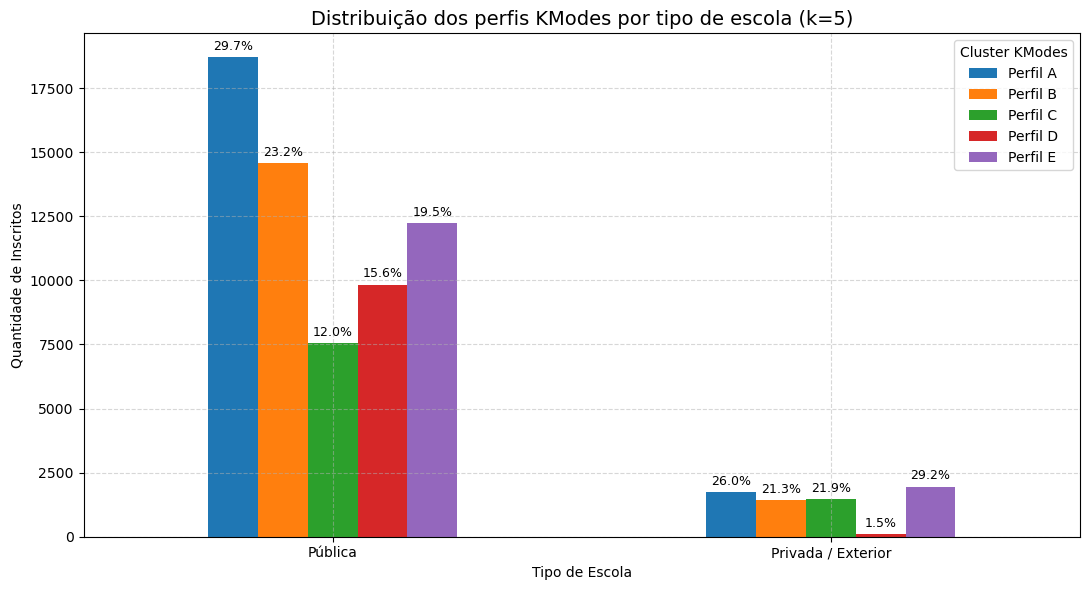


Resumo total por cluster KModes:
          Quantidade  Porcentagem
Cluster                          
Perfil A       20441         29.4
Perfil B       16006         23.0
Perfil C        9011         12.9
Perfil D        9939         14.3
Perfil E       14197         20.4


In [13]:
nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D",
    4: "Perfil E"
}

df_k = df_ifnmg.copy()
df_k["Cluster"] = df_k["Cluster_KModes"].map(nomes_clusters)

cols = ["TP_ESCOLA", "Cluster"]
base = df_k[cols].dropna().copy()

mapa_escola = {
    0: "Pública",
    1: "Privada / Exterior"
}

ordem_escola = [0, 1]

base["TP_ESCOLA"] = pd.Categorical(
    base["TP_ESCOLA"],
    categories=ordem_escola,
    ordered=True
)

contagem = (
    base.groupby(["TP_ESCOLA", "Cluster"], observed=True)
        .size()
        .rename("Quantidade")
        .reset_index()
)

tabela = (
    contagem.pivot_table(
        index="TP_ESCOLA", columns="Cluster", values="Quantidade",
        aggfunc="sum", observed=True
    )
    .reindex(index=ordem_escola, columns=list(nomes_clusters.values()))
    .fillna(0)
    .astype(int)
)

tabela.index = [mapa_escola[i] for i in tabela.index]

percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

ax = tabela.plot(kind="bar", figsize=(11, 6))
ax.set_title("Distribuição dos perfis KModes por tipo de escola (k=5)", fontsize=14)
ax.set_xlabel("Tipo de Escola")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Cluster KModes")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=0)

for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

tabela_total = tabela.sum().to_frame(name="Quantidade")
tabela_total["Porcentagem"] = (
    tabela_total["Quantidade"] / tabela_total["Quantidade"].sum() * 100
).round(1)

print("\nResumo total por cluster KModes:")
print(tabela_total)

Nota-se que a maior concentração de candidatos provém de escolas públicas, representando a maioria em todos os clusters. Dentro desse grupo, o Perfil A se destaca como o mais numeroso, seguido pelos perfis B e E, enquanto os perfis C e D aparecem com menor representação, ainda que com participação significativa.

Por outro lado, entre os inscritos provenientes de escolas privadas ou do exterior, observa-se uma redução expressiva no volume total, porém com maior equilíbrio percentual entre os perfis. O Perfil A continua em destaque, mas com diferença menos acentuada em relação aos demais perfis quando comparado ao cenário das escolas públicas. Os clusters B e C mantêm participação relevante nesse segmento, enquanto o Perfil D apresenta baixa incidência, e o Perfil E assume uma representatividade proporcionalmente maior no contexto das escolas privadas.

## **Quantidade de inscritos por grupo para cada gênero**

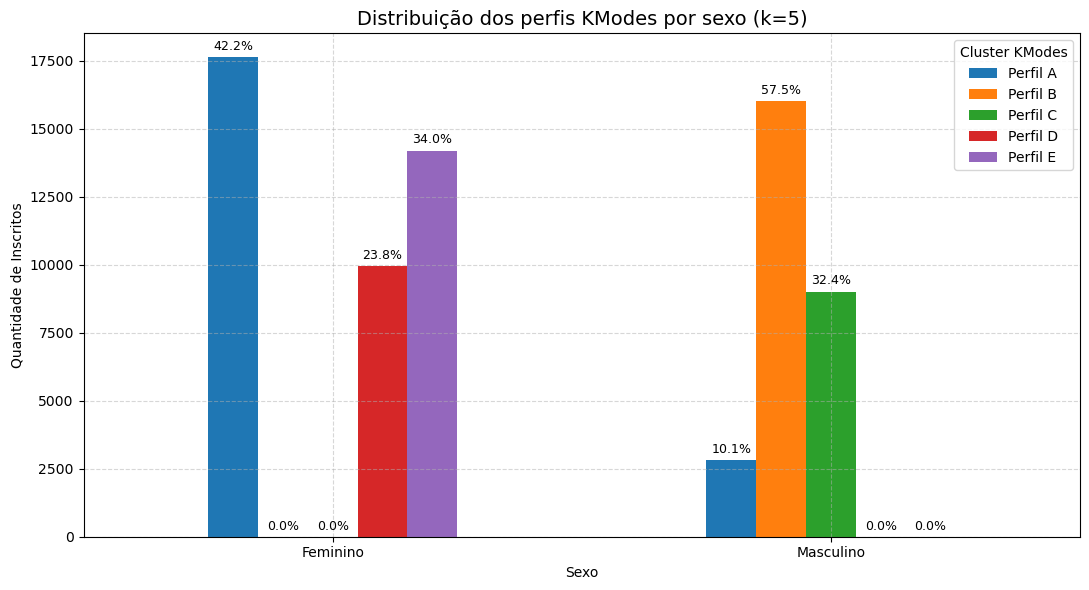


Resumo total por cluster KModes:
          Quantidade  Porcentagem
Cluster                          
Perfil A       20441         29.4
Perfil B       16006         23.0
Perfil C        9011         12.9
Perfil D        9939         14.3
Perfil E       14197         20.4


In [14]:
nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D",
    4: "Perfil E"
}

df_k = df_ifnmg.copy()
df_k["Cluster"] = df_k["Cluster_KModes"].map(nomes_clusters)

cols = ["TP_SEXO", "Cluster"]
base = df_k[cols].dropna().copy()

mapa_sexo = {
    1: "Feminino",
    0: "Masculino"
}

ordem_sexo = [1, 0]  

base["TP_SEXO"] = pd.Categorical(
    base["TP_SEXO"],
    categories=ordem_sexo,
    ordered=True
)

contagem = (
    base.groupby(["TP_SEXO", "Cluster"], observed=True)
        .size()
        .rename("Quantidade")
        .reset_index()
)

tabela = (
    contagem.pivot_table(
        index="TP_SEXO", columns="Cluster", values="Quantidade",
        aggfunc="sum", observed=True
    )
    .reindex(index=ordem_sexo, columns=list(nomes_clusters.values()))
    .fillna(0)
    .astype(int)
)


tabela.index = [mapa_sexo[i] for i in tabela.index]

percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

ax = tabela.plot(kind="bar", figsize=(11, 6))

ax.set_title("Distribuição dos perfis KModes por sexo (k=5)", fontsize=14)
ax.set_xlabel("Sexo")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Cluster KModes")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=0)


for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

tabela_total = tabela.sum().to_frame(name="Quantidade")
tabela_total["Porcentagem"] = (
    tabela_total["Quantidade"] / tabela_total["Quantidade"].sum() * 100
).round(1)

print("\nResumo total por cluster KModes:")
print(tabela_total)

O Perfil A destaca-se como o mais numeroso nesse grupo, seguido pelo Perfil E e pelo Perfil D, enquanto os perfis B e C possuem presença praticamente inexistente entre as mulheres. Esse resultado sugere características específicas que aproximam o perfil A e E do público feminino, indicando maior aderência dessas categorias às condições ou comportamentos predominantes nesse grupo.

Por outro lado, no grupo masculino, o Perfil B aparece com maior representatividade, seguido pelo Perfil C e pelo Perfil A, evidenciando um padrão distinto daquele observado entre as mulheres. Os perfis D e E não apresentam presença relevante entre os homens, reforçando a distinção comportamental entre os sexos no conjunto analisado.

De forma geral, os dados evidenciam que a composição dos clusters varia fortemente segundo o sexo, indicando que homens e mulheres tendem a se concentrar em perfis diferentes dentro da segmentação realizada pelo algoritmo. 

## **Quantidade de inscritos por grupo para cada cor/raça**

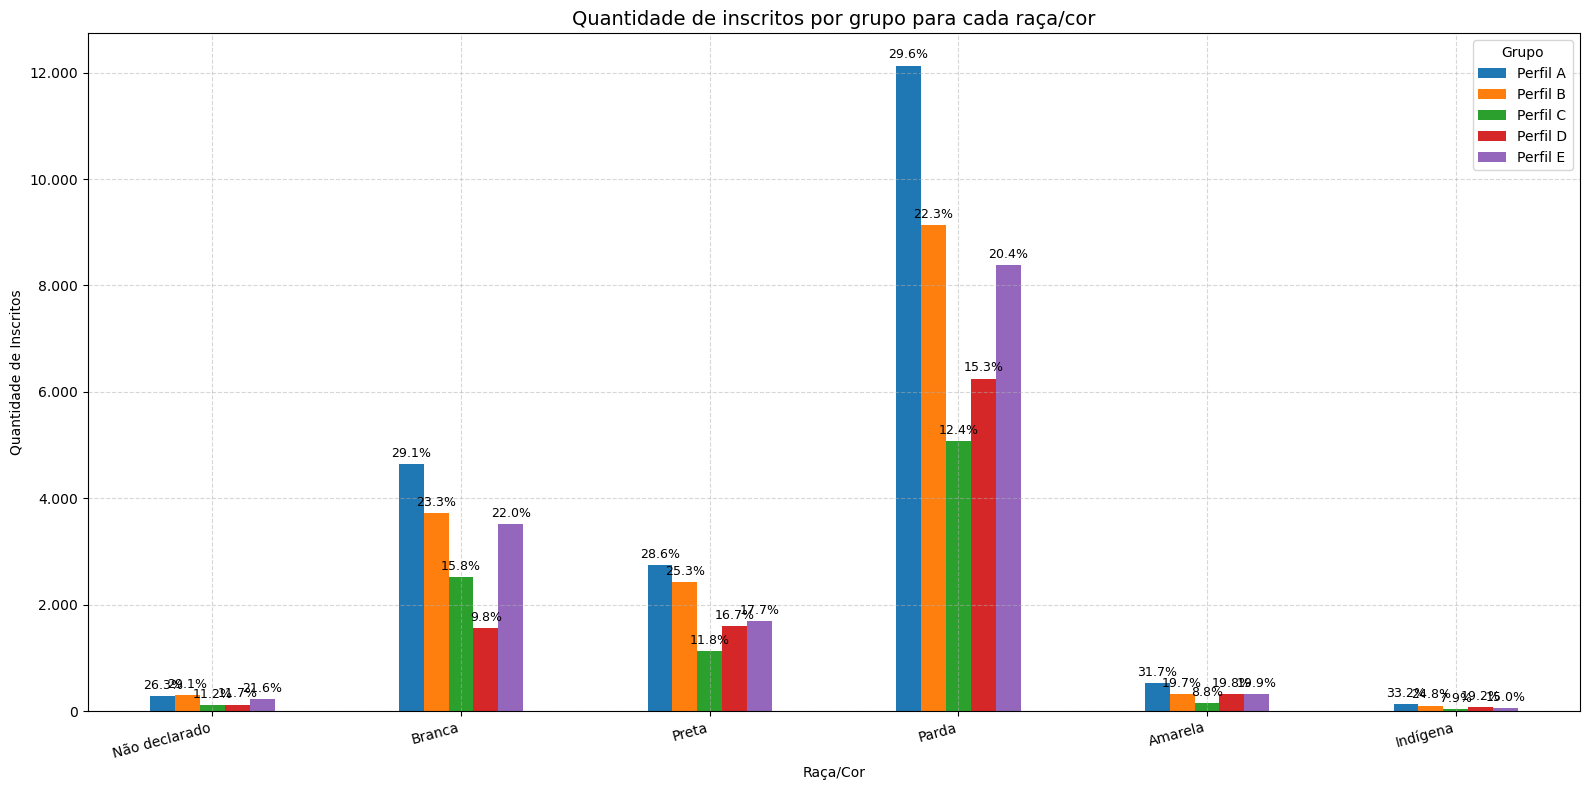


Resumo total por cluster KModes:
          Quantidade  Porcentagem
Cluster                          
Perfil A       20441         29.4
Perfil B       16006         23.0
Perfil C        9011         12.9
Perfil D        9939         14.3
Perfil E       14197         20.4


In [15]:
df_k = df_ifnmg.copy()

if "TP_COR_RACA" not in df_k.columns:
    cols_raca = [c for c in df_k.columns if c.startswith("COR_RACA_")]
    if not cols_raca:
        raise ValueError("Não encontrei TP_COR_RACA nem colunas COR_RACA_*.")
    
    df_k["TP_COR_RACA"] = (
        df_k[cols_raca]
        .idxmax(axis=1)              # seleciona a coluna onde está o 1
        .str.replace("COR_RACA_", "")
        .astype(int)
    )

nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D",
    4: "Perfil E"
}

df_k["Cluster"] = df_k["Cluster_KModes"].map(nomes_clusters)

base = df_k[["TP_COR_RACA", "Cluster"]].dropna().copy()

ordem_raca = [0, 1, 2, 3, 4, 5]

mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena"
}

base["TP_COR_RACA"] = pd.Categorical(base["TP_COR_RACA"], categories=ordem_raca, ordered=True)

contagem = (
    base.groupby(["TP_COR_RACA", "Cluster"], observed=True)
        .size()
        .reset_index(name="Quantidade")
)

tabela = (
    contagem.pivot(index="TP_COR_RACA", columns="Cluster", values="Quantidade")
           .reindex(index=ordem_raca, columns=list(nomes_clusters.values()))
           .fillna(0)
           .astype(int)
)

tabela.index = [mapa_raca[i] for i in tabela.index]

percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))

tabela.plot(kind="bar", ax=ax)

ax.set_title("Quantidade de inscritos por grupo para cada raça/cor", fontsize=14)
ax.set_xlabel("Raça/Cor")
ax.set_ylabel("Quantidade de Inscritos")
ax.set_xticklabels(tabela.index, rotation=15, ha="right")

ax.legend(title="Grupo")
ax.grid(True, linestyle="--", alpha=0.5)

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))

for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

tabela_total = tabela.sum().to_frame(name="Quantidade")
tabela_total["Porcentagem"] = (
    tabela_total["Quantidade"] / tabela_total["Quantidade"].sum() * 100
).round(1)

print("\nResumo total por cluster KModes:")
print(tabela_total)

Nota-se que o grupo Parda concentra a maior quantidade de participantes em todos os perfis, com destaque para o Perfil A, que representa parcela significativamente superior aos demais perfis dentro dessa categoria. Em seguida, observa-se a categoria Branca, também com ampla representatividade, especialmente nos perfis A, B e E, enquanto os perfis C e D aparecem com participação menor, embora ainda relevante.

Na categoria Preta, os perfis A e B novamente se destacam, mantendo um comportamento semelhante aos grupos anteriores, enquanto C, D e E aparecem com proporções menores. Já nas categorias de menor frequência — Amarela, Indígena e Não declarado — observa-se uma distribuição mais equilibrada, porém com números absolutos reduzidos quando comparados aos demais grupos raciais. Nessas categorias, o Perfil A permanece entre os mais representados, ainda que com diferença menos acentuada, enquanto os demais perfis apresentam distribuição proporcional mais próxima.

De maneira geral, a análise revela que os perfis gerados pelo algoritmo apresentam forte concentração entre candidatos que se autodeclaram pardos e brancos, o que reflete a composição predominante do conjunto amostral. Além disso, o fato de diferentes perfis se distribuírem de forma semelhante entre as principais categorias raciais pode indicar que, embora a raça/cor influencie a composição quantitativa dos inscritos, os grupos formados pelos clusters não são rigidamente segregados por esse atributo, sugerindo diversidade interna dentro dos perfis.

## **Quantidade de inscritos por grupo para cada faixa de renda mensal**

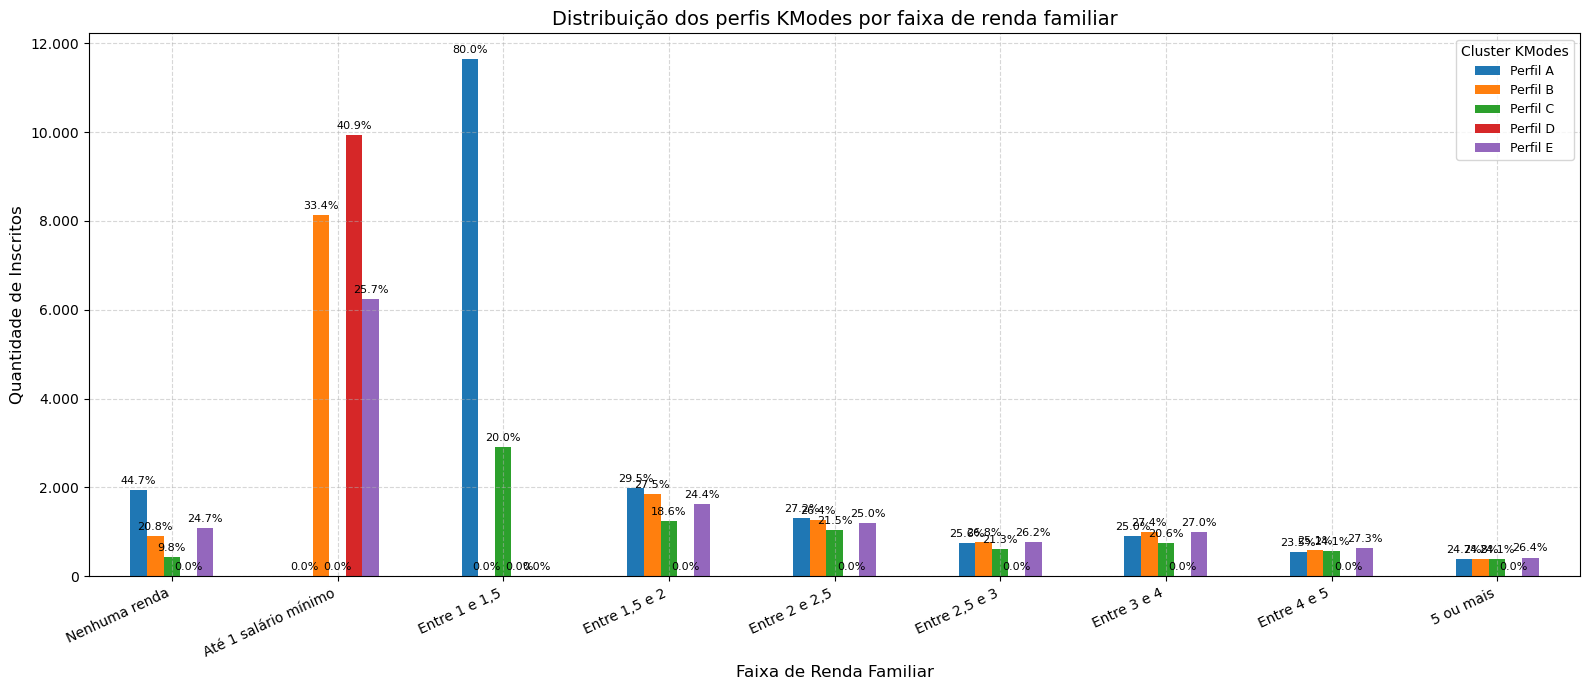


Resumo total por cluster KModes:
          Quantidade  Porcentagem
Cluster                          
Perfil A       19493         29.9
Perfil B       14927         22.9
Perfil C        7955         12.2
Perfil D        9939         15.2
Perfil E       12985         19.9


In [16]:
df_k = df_final.copy()

nomes_clusters = {
    0: "Perfil A",
    1: "Perfil B",
    2: "Perfil C",
    3: "Perfil D",
    4: "Perfil E"
}

df_k["Cluster"] = df_k["Cluster_KModes"].map(nomes_clusters)

mapa_renda_num = {
    0: "Nenhuma renda",
    1: "Até 1 salário mínimo",
    2: "Entre 1 e 1,5",
    3: "Entre 1,5 e 2",
    4: "Entre 2 e 2,5",
    5: "Entre 2,5 e 3",
    6: "Entre 3 e 4",
    7: "Entre 4 e 5",
    8: "5 ou mais"
}

df_k = df_k[df_k["RENDA_MENSAL"].isin(mapa_renda_num.keys())].copy()
df_k["Faixa_Renda"] = df_k["RENDA_MENSAL"].map(mapa_renda_num)

ordem_renda = list(mapa_renda_num.values())
ordem_clusters = list(nomes_clusters.values())

contagem = (
    df_k.groupby(["Faixa_Renda", "Cluster"], observed=True)
        .size()
        .reset_index(name="Quantidade")
)

tabela = (
    contagem.pivot(index="Faixa_Renda", columns="Cluster", values="Quantidade")
            .reindex(index=ordem_renda, columns=ordem_clusters)
            .fillna(0)
            .astype(int)
)

percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 7))
tabela.plot(kind="bar", ax=ax)

ax.set_title("Distribuição dos perfis KModes por faixa de renda familiar", fontsize=14)
ax.set_xlabel("Faixa de Renda Familiar", fontsize=12)
ax.set_ylabel("Quantidade de Inscritos", fontsize=12)
ax.set_xticklabels(tabela.index, rotation=25, ha="right")

ax.legend(title="Cluster KModes", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))

for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.tight_layout()
plt.show()

tabela_total = tabela.sum().to_frame(name="Quantidade")
tabela_total["Porcentagem"] = (
    tabela_total["Quantidade"] / tabela_total["Quantidade"].sum() * 100
).round(1)

print("\nResumo total por cluster KModes:")
print(tabela_total)

Observa-se inicialmente que, entre candidatos sem renda, há maior concentração no Perfil A, seguido pelos perfis E e B, enquanto os perfis C e D aparecem com participação menor. Essa predominância sugere que o Perfil A contempla um grupo com maior vulnerabilidade socioeconômica.

A faixa até 1 salário mínimo apresenta comportamento distinto, com destaque para o Perfil D, que representa a maior parcela dos inscritos nessa categoria, seguido pelos perfis B e E. A presença reduzida dos perfis A e C nessa faixa indica possíveis características socioeducacionais específicas que diferenciam esse grupo dos demais.

Nas faixas intermediárias, em especial entre 1,5 e 2 salários mínimos e entre 2 e 2,5 salários, observa-se uma distribuição mais equilibrada entre perfis, com destaque para o Perfil A e o Perfil E nas faixas até 2 salários, enquanto o Perfil B mantém participação moderada. Já o Perfil C apresenta crescimento relativo em faixas entre 1 e 1,5 e 1,5 e 2 salários, indicando maior concentração de inscritos com rendimento familiar levemente superior aos grupos iniciais.

A partir de 2,5 salários até 4 salários mínimos, as proporções entre os perfis tornam-se mais homogêneas, sem grandes discrepâncias, sugerindo maior diversidade no agrupamento para essas classes de renda. Já nas faixas superiores, entre 4 e 5 salários e 5 ou mais salários, a distribuição se estabiliza e permanece relativamente próxima entre os perfis A, B, C e E, enquanto o Perfil D deixa de aparecer com relevância nessas faixas, indicando menor presença de indivíduos desse grupo entre os inscritos com maior renda familiar.

De forma geral, os resultados sugerem que a renda familiar influencia a composição dos clusters, sobretudo nas faixas iniciais, onde a predominância de determinados perfis evidencia maior concentração de inscritos em situação econômica mais sensível. À medida que a renda aumenta, os grupos se tornam mais distribuídos, indicando menor distinção entre perfis em níveis socioeconômicos mais elevados.